# N-BEATS vs LSTM Benchmark Comparison
**Dataset:** Air Passengers  
**Tuning:** Bayesian Optimization (Optuna TPE)  
**Metrics:** sMAPE, MAE, RMSE, MAPE

In [ ]:
# Cell 1 — Install & Imports
!pip install optuna -q

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import optuna
import matplotlib.pyplot as plt
import pandas as pd
optuna.logging.set_verbosity(optuna.logging.WARNING)
print('All imports done!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.2 MB/s eta 0:00:00
All imports done!


In [ ]:
# Cell 2 — NBeatsBlock
class NBeatsBlock(nn.Module):
    def __init__(self, input_size, theta_size, horizon, n_layers, hidden_size, basis_function):
        super().__init__()
        self.horizon        = horizon
        self.input_size     = input_size
        self.basis_function = basis_function

        layers = [nn.Linear(input_size, hidden_size), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.ReLU()]
        self.fc_stack = nn.Sequential(*layers)

        self.theta_b = nn.Linear(hidden_size, theta_size, bias=False)
        self.theta_f = nn.Linear(hidden_size, theta_size, bias=False)

    def forward(self, x):
        h        = self.fc_stack(x)
        theta_b  = self.theta_b(h)
        theta_f  = self.theta_f(h)
        backcast = self.basis_function.backcast(theta_b, self.input_size)
        forecast = self.basis_function.forecast(theta_f, self.horizon)
        return backcast, forecast

print('NBeatsBlock defined!')

NBeatsBlock defined!


In [ ]:
# Cell 3 — Basis Functions
class GenericBasis(nn.Module):
    def __init__(self, theta_size, input_size, horizon):
        super().__init__()
        self.W_b = nn.Linear(theta_size, input_size, bias=False)
        self.W_f = nn.Linear(theta_size, horizon,    bias=False)

    def backcast(self, theta, input_size): return self.W_b(theta)
    def forecast(self, theta, horizon):    return self.W_f(theta)


class TrendBasis(nn.Module):
    def __init__(self, degree, input_size, horizon):
        super().__init__()
        t_f = torch.arange(horizon,     dtype=torch.float32) / horizon
        t_b = torch.arange(-input_size, 0, dtype=torch.float32) / horizon
        T_f = torch.stack([t_f ** i for i in range(degree + 1)], dim=1)
        T_b = torch.stack([t_b ** i for i in range(degree + 1)], dim=1)
        self.register_buffer('T_f', T_f)
        self.register_buffer('T_b', T_b)

    def backcast(self, theta, input_size): return theta @ self.T_b.T
    def forecast(self, theta, horizon):    return theta @ self.T_f.T


class SeasonalityBasis(nn.Module):
    def __init__(self, input_size, horizon):
        super().__init__()
        half  = horizon // 2
        freqs = torch.arange(1, half, dtype=torch.float32)

        t_f   = torch.arange(horizon, dtype=torch.float32) / horizon
        cos_f = torch.cos(2 * torch.pi * freqs[:, None] * t_f[None, :])
        sin_f = torch.sin(2 * torch.pi * freqs[:, None] * t_f[None, :])
        S_f   = torch.cat([torch.ones(1, horizon), cos_f, sin_f], dim=0)
        self.register_buffer('S_f', S_f)

        t_b   = torch.arange(-input_size, 0, dtype=torch.float32) / horizon
        cos_b = torch.cos(2 * torch.pi * freqs[:, None] * t_b[None, :])
        sin_b = torch.sin(2 * torch.pi * freqs[:, None] * t_b[None, :])
        S_b   = torch.cat([torch.ones(1, input_size), cos_b, sin_b], dim=0)
        self.register_buffer('S_b', S_b)

        self.n_params = S_f.shape[0]

    def backcast(self, theta, input_size): return theta @ self.S_b
    def forecast(self, theta, horizon):    return theta @ self.S_f

print('Basis functions defined!')

Basis functions defined!


In [ ]:
# Cell 4 — NBeatsStack
class NBeatsStack(nn.Module):
    def __init__(self, blocks):
        super().__init__()
        self.blocks = nn.ModuleList(blocks)

    def forward(self, x):
        stack_forecast = 0.0
        for block in self.blocks:
            backcast, forecast = block(x)
            x              = x - backcast
            stack_forecast = stack_forecast + forecast
        return x, stack_forecast

print('NBeatsStack defined!')

NBeatsStack defined!


In [ ]:
# Cell 5 — NBeats Models
class NBeatsGeneric(nn.Module):
    def __init__(self, input_size, horizon, n_stacks=30, n_blocks=1,
                 n_layers=4, hidden_size=512):
        super().__init__()
        theta_size = hidden_size
        stacks = []
        for _ in range(n_stacks):
            blocks = []
            for _ in range(n_blocks):
                basis = GenericBasis(theta_size, input_size, horizon)
                block = NBeatsBlock(input_size, theta_size, horizon,
                                    n_layers, hidden_size, basis)
                blocks.append(block)
            stacks.append(NBeatsStack(blocks))
        self.stacks = nn.ModuleList(stacks)

    def forward(self, x):
        global_forecast = 0.0
        for stack in self.stacks:
            x, sf           = stack(x)
            global_forecast = global_forecast + sf
        return global_forecast


class NBeatsInterpretable(nn.Module):
    def __init__(self, input_size, horizon, trend_blocks=3, season_blocks=3,
                 trend_layers=4, season_layers=4,
                 trend_hidden=256, season_hidden=2048, degree=2):
        super().__init__()
        trend_basis      = TrendBasis(degree, input_size, horizon)
        shared_trend     = NBeatsBlock(input_size, degree + 1, horizon,
                                       trend_layers, trend_hidden, trend_basis)
        self.trend_stack = NBeatsStack([shared_trend] * trend_blocks)

        season_basis      = SeasonalityBasis(input_size, horizon)
        shared_season     = NBeatsBlock(input_size, season_basis.n_params, horizon,
                                        season_layers, season_hidden, season_basis)
        self.season_stack = NBeatsStack([shared_season] * season_blocks)

    def forward(self, x):
        x, trend  = self.trend_stack(x)
        _, season = self.season_stack(x)
        return trend + season, trend, season

print('NBeats models defined!')

NBeats models defined!


In [ ]:
# Cell 6 — LSTM Benchmark Model
class LSTMForecast(nn.Module):
    """
    Vanilla LSTM baseline for benchmark comparison.
    Input  : (batch, input_size)
    Output : (batch, horizon)
    """
    def __init__(self, input_size, horizon, hidden_size=128,
                 num_layers=2, dropout=0.2):
        super().__init__()
        self.input_size  = input_size
        self.horizon     = horizon
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(
            input_size  = 1,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        x           = x.unsqueeze(-1)
        out, _      = self.lstm(x)
        last_hidden = out[:, -1, :]
        last_hidden = self.dropout(last_hidden)
        return self.fc(last_hidden)

print('LSTM model defined!')

LSTM model defined!


In [ ]:
# Cell 7 — Dataset, Loss & Data Loading
class TimeSeriesWindowDataset(Dataset):
    def __init__(self, series, input_size, horizon):
        self.series     = torch.tensor(series, dtype=torch.float32)
        self.input_size = input_size
        self.horizon    = horizon
        self.n          = len(series) - input_size - horizon + 1

    def __len__(self):  return self.n

    def __getitem__(self, i):
        x = self.series[i : i + self.input_size]
        y = self.series[i + self.input_size : i + self.input_size + self.horizon]
        return x, y


def smape_loss(forecast, target, eps=1e-8):
    denom = (target.abs() + forecast.abs()).detach() + eps
    return (200.0 * (forecast - target).abs() / denom).mean()

def mae(forecast, target):
    return np.mean(np.abs(forecast - target))

def rmse(forecast, target):
    return np.sqrt(np.mean((forecast - target) ** 2))

def mape(forecast, target, eps=1e-8):
    return np.mean(np.abs((forecast - target) / (np.abs(target) + eps))) * 100


# Load Air Passengers
url    = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df     = pd.read_csv(url, header=0, usecols=[1])
series = df.values.flatten().astype(np.float32)

mu, std = series.mean(), series.std()
series_norm = (series - mu) / std

n       = len(series_norm)
n_train = int(n * 0.80)
n_val   = int(n * 0.10)

H          = 12
input_size = 3 * H
device     = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Total: {n} | Train: {n_train} | Val: {n_val} | Device: {device}')

train_s = series_norm[:n_train]
val_s   = series_norm[n_train - input_size : n_train + n_val]
test_s  = series_norm[n_train + n_val - input_size :]

train_loader = DataLoader(TimeSeriesWindowDataset(train_s, input_size, H),
                          batch_size=16, shuffle=True)
val_loader   = DataLoader(TimeSeriesWindowDataset(val_s,   input_size, H),
                          batch_size=16, shuffle=False)
test_dataset = TimeSeriesWindowDataset(test_s, input_size, H)

print(f'Train windows: {len(train_loader.dataset)} | Val windows: {len(val_loader.dataset)}')

Total: 144 | Train: 115 | Val: 14 | Device: cpu
Train windows: 68 | Val windows: 3


In [ ]:
# Cell 8 — Bayesian Optimization for N-BEATS
def train_and_evaluate_nbeats(params, epochs=20):
    model = NBeatsGeneric(
        input_size  = input_size,
        horizon     = H,
        n_stacks    = params['n_stacks'],
        n_blocks    = params['n_blocks'],
        n_layers    = params['n_layers'],
        hidden_size = params['hidden_size']
    ).to(device)

    opt       = torch.optim.Adam(model.parameters(), lr=params['lr'],
                                 weight_decay=params['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            smape_loss(model(xb), yb).backward()
            opt.step()
        scheduler.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += smape_loss(model(xb), yb).item()
    return val_loss / len(val_loader)


def nbeats_objective(trial):
    params = {
        'n_stacks'    : trial.suggest_int('n_stacks',    3,  20),
        'n_blocks'    : trial.suggest_int('n_blocks',    1,   3),
        'n_layers'    : trial.suggest_int('n_layers',    2,   5),
        'hidden_size' : trial.suggest_categorical('hidden_size', [64, 128, 256, 512]),
        'lr'          : trial.suggest_float('lr',          1e-4, 1e-2, log=True),
        'weight_decay': trial.suggest_float('weight_decay',1e-6, 1e-3, log=True),
    }
    return train_and_evaluate_nbeats(params, epochs=20)


print('Bayesian Optimization for N-BEATS (30 trials)...')
nbeats_study = optuna.create_study(
    direction = 'minimize',
    sampler   = optuna.samplers.TPESampler(seed=42),
    pruner    = optuna.pruners.MedianPruner()
)
nbeats_study.optimize(nbeats_objective, n_trials=30, show_progress_bar=True)

print(f'\nBest N-BEATS Val sMAPE : {nbeats_study.best_value:.4f}')
print(f'Best N-BEATS Params    : {nbeats_study.best_params}')

Bayesian Optimization for N-BEATS (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


Best N-BEATS Val sMAPE : 26.8379
Best N-BEATS Params    : {'n_stacks': 17, 'n_blocks': 2, 'n_layers': 4, 'hidden_size': 128, 'lr': 0.003764953526996652, 'weight_decay': 2.4024488846610613e-06}


In [ ]:
# Cell 9 — Bayesian Optimization for LSTM
def train_and_evaluate_lstm(params, epochs=20):
    model = LSTMForecast(
        input_size  = input_size,
        horizon     = H,
        hidden_size = params['hidden_size'],
        num_layers  = params['num_layers'],
        dropout     = params['dropout']
    ).to(device)

    opt       = torch.optim.Adam(model.parameters(), lr=params['lr'],
                                 weight_decay=params['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            smape_loss(model(xb), yb).backward()
            opt.step()
        scheduler.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += smape_loss(model(xb), yb).item()
    return val_loss / len(val_loader)


def lstm_objective(trial):
    params = {
        'hidden_size' : trial.suggest_categorical('hidden_size', [64, 128, 256, 512]),
        'num_layers'  : trial.suggest_int('num_layers',  1,   3),
        'dropout'     : trial.suggest_float('dropout',   0.0, 0.5),
        'lr'          : trial.suggest_float('lr',        1e-4, 1e-2, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True),
    }
    return train_and_evaluate_lstm(params, epochs=20)


print('Bayesian Optimization for LSTM (30 trials)...')
lstm_study = optuna.create_study(
    direction = 'minimize',
    sampler   = optuna.samplers.TPESampler(seed=42),
    pruner    = optuna.pruners.MedianPruner()
)
lstm_study.optimize(lstm_objective, n_trials=30, show_progress_bar=True)

print(f'\nBest LSTM Val sMAPE : {lstm_study.best_value:.4f}')
print(f'Best LSTM Params    : {lstm_study.best_params}')

Bayesian Optimization for LSTM (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


Best LSTM Val sMAPE : 29.7837
Best LSTM Params    : {'hidden_size': 512, 'num_layers': 1, 'dropout': 0.4876950181958492, 'lr': 0.005492954028045404, 'weight_decay': 1.9739584183449646e-06}


In [ ]:
# Cell 10 — Train Final Models with Best Params
def train_final(model, lr, wd, epochs=50):
    opt       = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    train_hist, val_hist = [], []

    for epoch in range(epochs):
        model.train()
        t_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            if isinstance(pred, tuple): pred = pred[0]
            loss = smape_loss(pred, yb)
            loss.backward(); opt.step()
            t_loss += loss.item()
        scheduler.step()
        train_hist.append(t_loss / len(train_loader))

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                if isinstance(pred, tuple): pred = pred[0]
                v_loss += smape_loss(pred, yb).item()
        val_hist.append(v_loss / len(val_loader))

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:02d}/50 | Train={train_hist[-1]:.4f} | Val={val_hist[-1]:.4f}')

    return train_hist, val_hist


# N-BEATS Generic
bp = nbeats_study.best_params
print('Training final N-BEATS Generic...')
final_nbeats_g = NBeatsGeneric(
    input_size=input_size, horizon=H,
    n_stacks=bp['n_stacks'], n_blocks=bp['n_blocks'],
    n_layers=bp['n_layers'], hidden_size=bp['hidden_size']
).to(device)
hist_ng_tr, hist_ng_val = train_final(final_nbeats_g, bp['lr'], bp['weight_decay'])

# N-BEATS Interpretable
print('\nTraining final N-BEATS Interpretable...')
final_nbeats_i = NBeatsInterpretable(
    input_size=input_size, horizon=H,
    trend_hidden=128, season_hidden=512, degree=2
).to(device)
hist_ni_tr, hist_ni_val = train_final(final_nbeats_i, bp['lr'], bp['weight_decay'])

# LSTM
lp = lstm_study.best_params
print('\nTraining final LSTM...')
final_lstm = LSTMForecast(
    input_size=input_size, horizon=H,
    hidden_size=lp['hidden_size'],
    num_layers=lp['num_layers'],
    dropout=lp['dropout']
).to(device)
hist_ls_tr, hist_ls_val = train_final(final_lstm, lp['lr'], lp['weight_decay'])

Training final N-BEATS Generic...
  Epoch 10/50 | Train=69.2250 | Val=47.4246
  Epoch 20/50 | Train=45.5762 | Val=33.8868
  Epoch 30/50 | Train=34.7657 | Val=32.6688
  Epoch 40/50 | Train=23.1984 | Val=29.2147
  Epoch 50/50 | Train=14.4243 | Val=27.1268

Training final N-BEATS Interpretable...
  Epoch 10/50 | Train=64.5344 | Val=38.5436
  Epoch 20/50 | Train=44.4411 | Val=17.0026
  Epoch 30/50 | Train=29.9749 | Val=14.1204
  Epoch 40/50 | Train=18.8892 | Val=15.1550
  Epoch 50/50 | Train=13.6396 | Val=10.3453

Training final LSTM...
  Epoch 10/50 | Train=107.6160 | Val=48.6543
  Epoch 20/50 | Train=99.8811 | Val=49.5050
  Epoch 30/50 | Train=66.1474 | Val=37.0649
  Epoch 40/50 | Train=67.3568 | Val=52.1924
  Epoch 50/50 | Train=62.6941 | Val=32.8434


In [ ]:
# Cell 11 — Benchmark Comparison Metrics
def get_test_forecast(model, test_dataset, mu, std):
    model.eval()
    all_preds, all_actuals = [], []
    with torch.no_grad():
        for i in range(len(test_dataset)):
            xb, yb = test_dataset[i]
            xb   = xb.unsqueeze(0).to(device)
            pred = model(xb)
            if isinstance(pred, tuple): pred = pred[0]
            pred_denorm   = pred.squeeze().cpu().numpy() * std + mu
            actual_denorm = yb.numpy() * std + mu
            all_preds.append(pred_denorm)
            all_actuals.append(actual_denorm)
    return np.array(all_preds), np.array(all_actuals)


preds_ng, acts_ng = get_test_forecast(final_nbeats_g, test_dataset, mu, std)
preds_ni, acts_ni = get_test_forecast(final_nbeats_i, test_dataset, mu, std)
preds_ls, acts_ls = get_test_forecast(final_lstm,     test_dataset, mu, std)

results = {
    'Model': ['N-BEATS Generic', 'N-BEATS Interpretable', 'LSTM'],
    'sMAPE': [
        smape_loss(torch.tensor(preds_ng), torch.tensor(acts_ng)).item(),
        smape_loss(torch.tensor(preds_ni), torch.tensor(acts_ni)).item(),
        smape_loss(torch.tensor(preds_ls), torch.tensor(acts_ls)).item(),
    ],
    'MAE':  [mae(preds_ng, acts_ng),  mae(preds_ni, acts_ni),  mae(preds_ls, acts_ls)],
    'RMSE': [rmse(preds_ng, acts_ng), rmse(preds_ni, acts_ni), rmse(preds_ls, acts_ls)],
    'MAPE': [mape(preds_ng, acts_ng), mape(preds_ni, acts_ni), mape(preds_ls, acts_ls)],
}
df_results = pd.DataFrame(results)
print('\n========= BENCHMARK COMPARISON =========')
print(df_results.to_string(index=False))
print('=========================================')


========= BENCHMARK COMPARISON =========
                Model     sMAPE       MAE      RMSE      MAPE
      N-BEATS Generic  5.883211 28.512367 35.314373  5.747615
N-BEATS Interpretable  3.604280 16.341358 19.016693  3.583734
                 LSTM 17.203772 78.113274 95.571983 15.422620


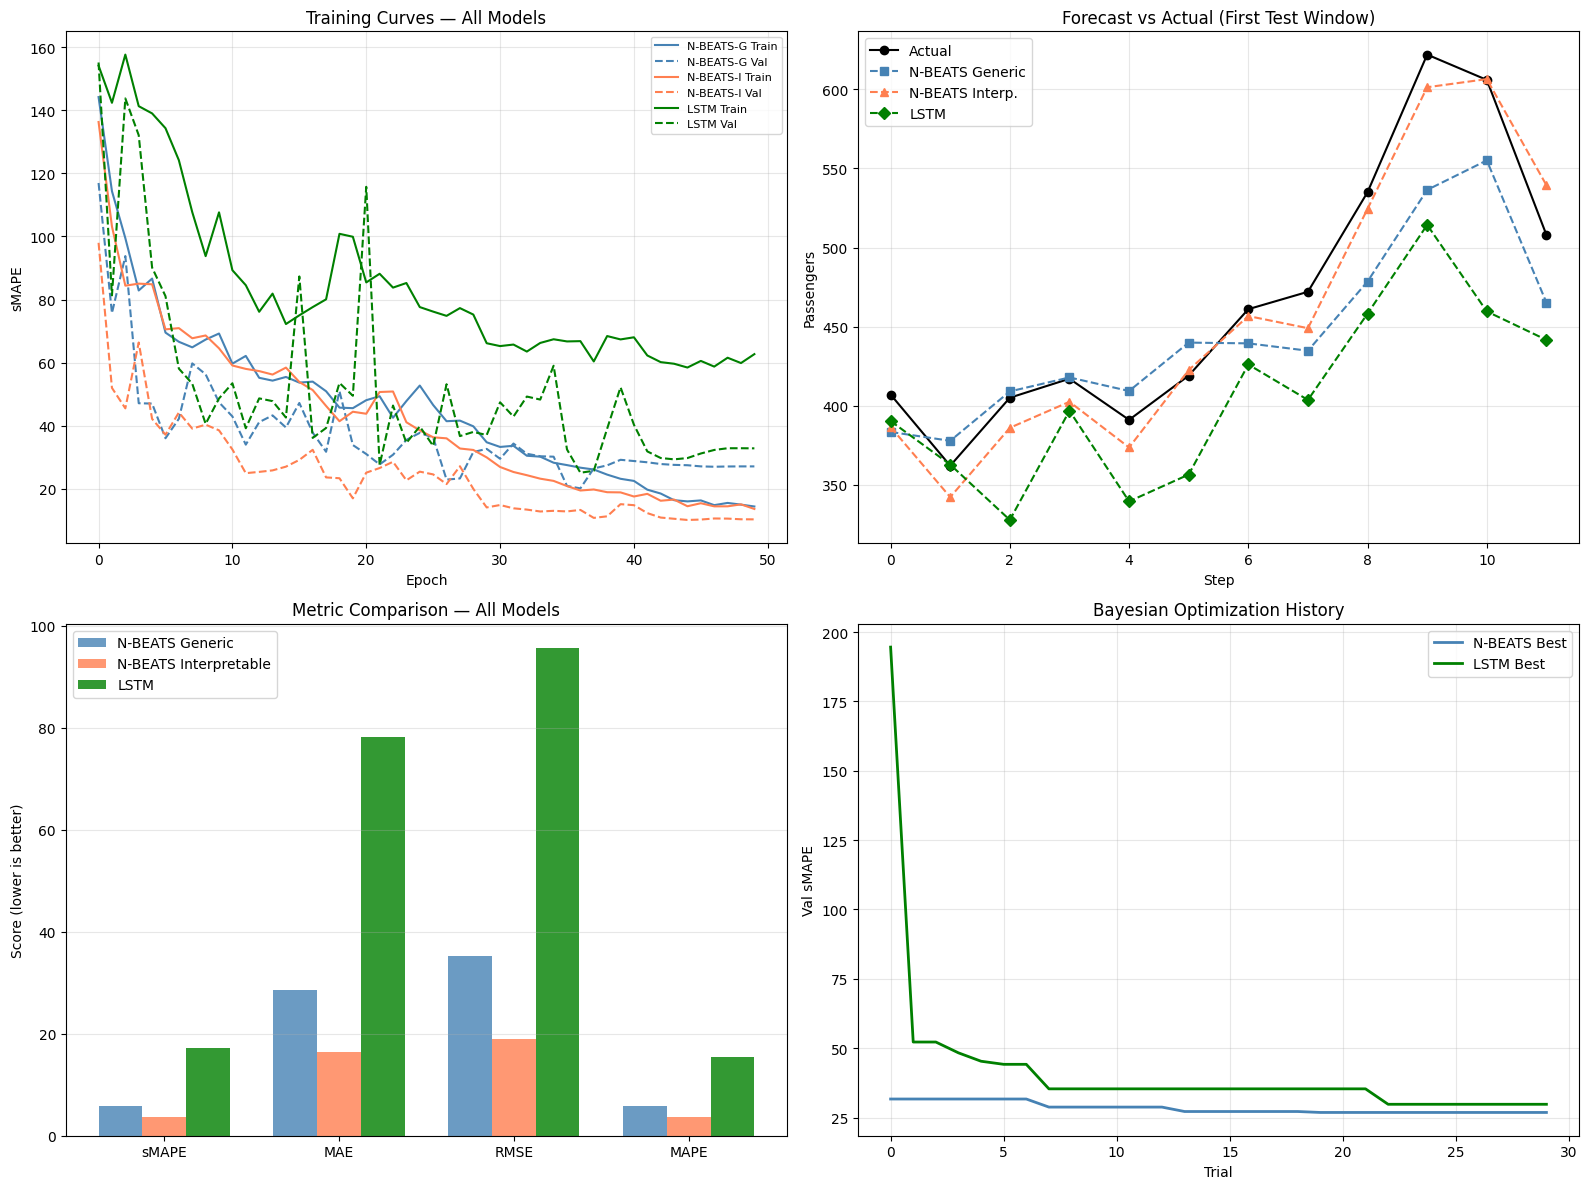

Plot saved as benchmark_comparison.png


In [ ]:
# Cell 12 — Final Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Training curves
axes[0,0].plot(hist_ng_tr,  label='N-BEATS-G Train', color='steelblue')
axes[0,0].plot(hist_ng_val, label='N-BEATS-G Val',   color='steelblue', linestyle='--')
axes[0,0].plot(hist_ni_tr,  label='N-BEATS-I Train', color='coral')
axes[0,0].plot(hist_ni_val, label='N-BEATS-I Val',   color='coral',     linestyle='--')
axes[0,0].plot(hist_ls_tr,  label='LSTM Train',      color='green')
axes[0,0].plot(hist_ls_val, label='LSTM Val',        color='green',     linestyle='--')
axes[0,0].set_title('Training Curves — All Models')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('sMAPE')
axes[0,0].legend(fontsize=8); axes[0,0].grid(True, alpha=0.3)

# Plot 2: Forecast vs Actual
axes[0,1].plot(acts_ng[0],  'o-',  label='Actual',          color='black')
axes[0,1].plot(preds_ng[0], 's--', label='N-BEATS Generic', color='steelblue')
axes[0,1].plot(preds_ni[0], '^--', label='N-BEATS Interp.', color='coral')
axes[0,1].plot(preds_ls[0], 'D--', label='LSTM',            color='green')
axes[0,1].set_title('Forecast vs Actual (First Test Window)')
axes[0,1].set_xlabel('Step'); axes[0,1].set_ylabel('Passengers')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# Plot 3: Metric bar chart
metrics = ['sMAPE', 'MAE', 'RMSE', 'MAPE']
models  = df_results['Model'].tolist()
x       = np.arange(len(metrics))
width   = 0.25
colors  = ['steelblue', 'coral', 'green']

for i, (model_name, color) in enumerate(zip(models, colors)):
    vals = [df_results.loc[i, m] for m in metrics]
    axes[1,0].bar(x + i * width, vals, width, label=model_name, color=color, alpha=0.8)

axes[1,0].set_title('Metric Comparison — All Models')
axes[1,0].set_xticks(x + width); axes[1,0].set_xticklabels(metrics)
axes[1,0].set_ylabel('Score (lower is better)')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3, axis='y')

# Plot 4: Bayesian Optimization history
for study, label, color in [
    (nbeats_study, 'N-BEATS', 'steelblue'),
    (lstm_study,   'LSTM',    'green')
]:
    vals = [t.value for t in study.trials if t.value is not None]
    best = [min(vals[:i+1]) for i in range(len(vals))]
    axes[1,1].plot(best, label=f'{label} Best', color=color, linewidth=2)

axes[1,1].set_title('Bayesian Optimization History')
axes[1,1].set_xlabel('Trial'); axes[1,1].set_ylabel('Val sMAPE')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as benchmark_comparison.png')

## Interpretable Component Analysis
Visualizing the **Trend** and **Seasonality** decomposition from N-BEATS Interpretable model.

In [ ]:
# Cell 13 — Extract Trend & Seasonality from N-BEATS Interpretable

final_nbeats_i.eval()

all_trends, all_seasons, all_forecasts, all_actuals = [], [], [], []

with torch.no_grad():
    for i in range(len(test_dataset)):
        xb, yb     = test_dataset[i]
        xb         = xb.unsqueeze(0).to(device)
        forecast, trend, season = final_nbeats_i(xb)

        # Denormalize
        forecast_d = forecast.squeeze().cpu().numpy() * std + mu
        trend_d    = trend.squeeze().cpu().numpy()    * std + mu
        season_d   = season.squeeze().cpu().numpy()   * std
        actual_d   = yb.numpy()                       * std + mu

        all_forecasts.append(forecast_d)
        all_trends.append(trend_d)
        all_seasons.append(season_d)
        all_actuals.append(actual_d)

all_forecasts = np.array(all_forecasts)
all_trends    = np.array(all_trends)
all_seasons   = np.array(all_seasons)
all_actuals   = np.array(all_actuals)

print(f'Test windows extracted: {len(all_forecasts)}')
print(f'Each window has {H} forecast steps')

Test windows extracted: 4
Each window has 12 forecast steps


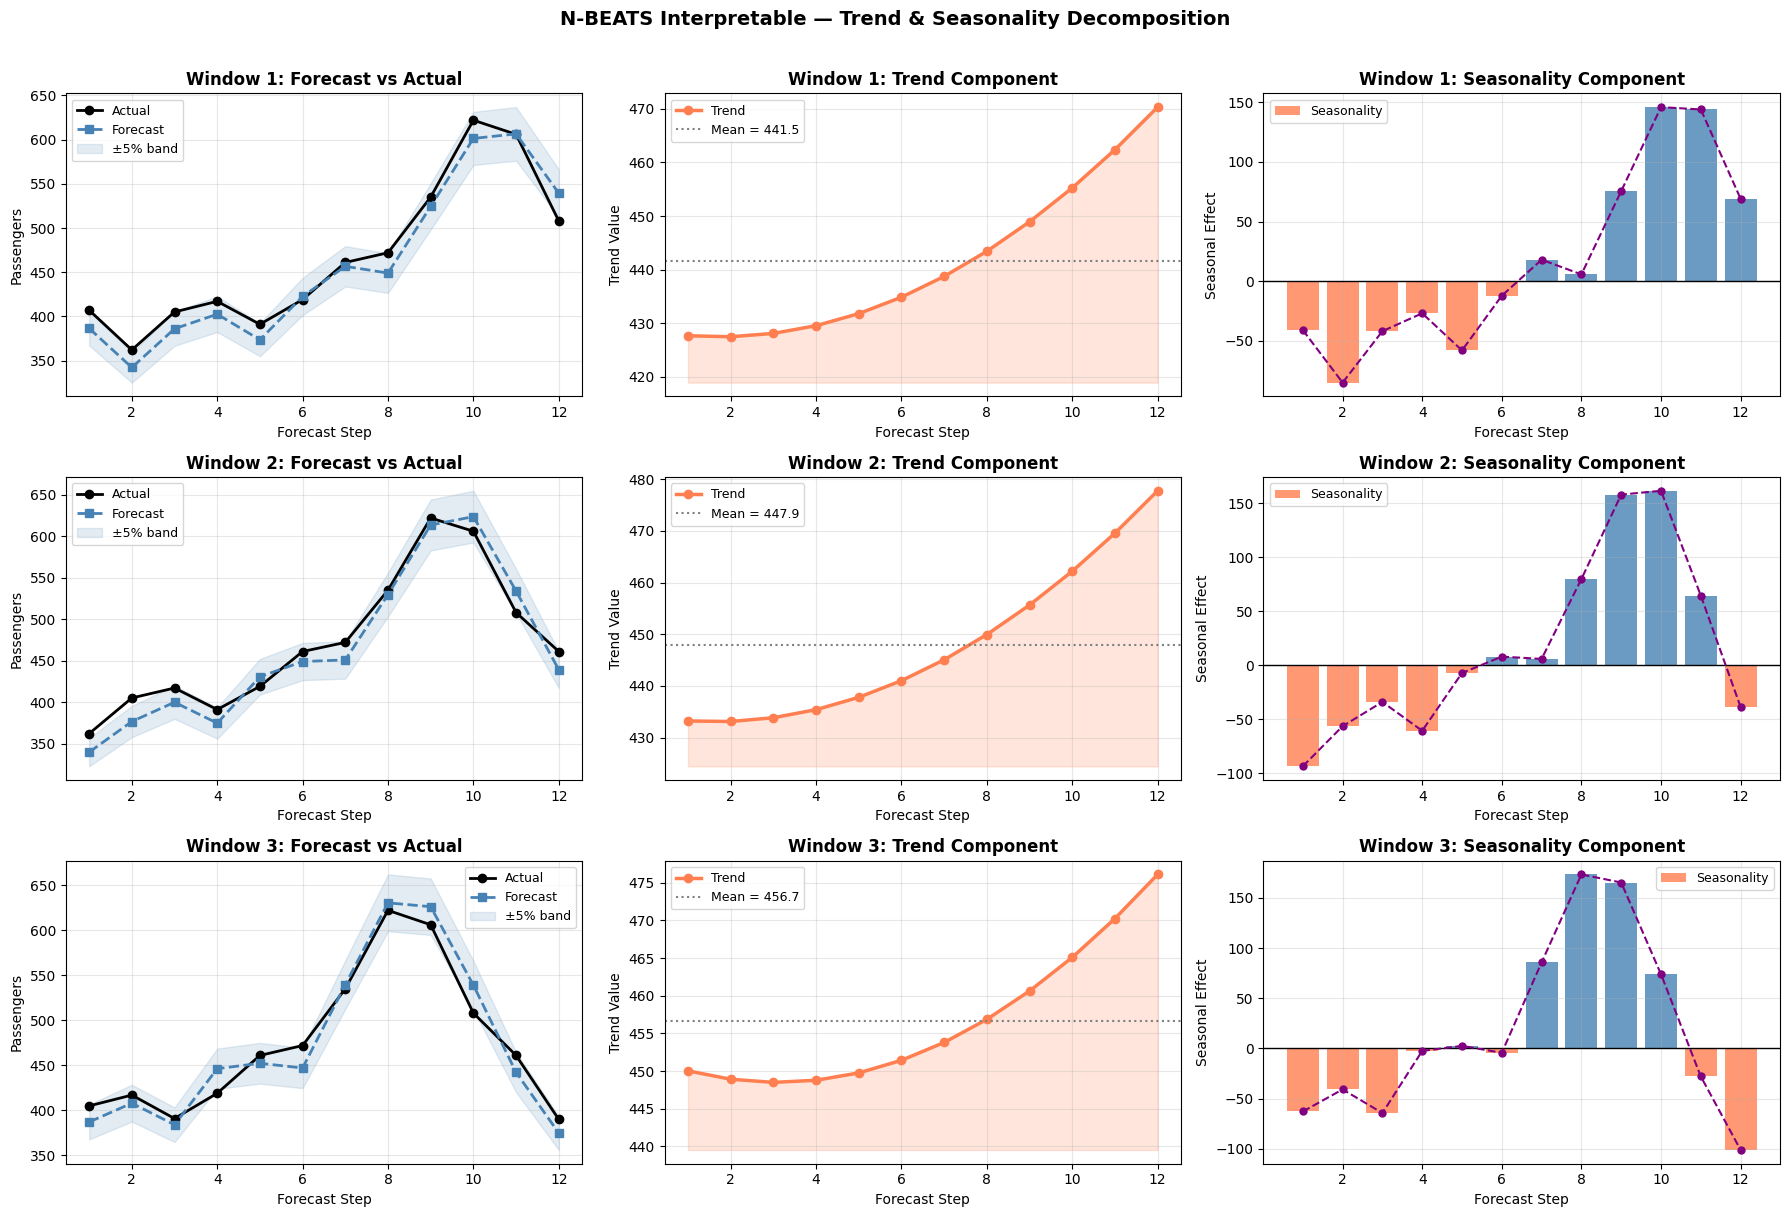

Saved: interpretable_decomposition.png


In [ ]:
# Cell 14 — Plot Trend & Seasonality for First 3 Test Windows

n_windows = min(3, len(all_forecasts))
fig, axes = plt.subplots(n_windows, 3, figsize=(18, 4 * n_windows))

if n_windows == 1:
    axes = axes.reshape(1, -1)

steps = np.arange(1, H + 1)

for w in range(n_windows):
    # --- Column 1: Forecast vs Actual ---
    axes[w, 0].plot(steps, all_actuals[w],   'o-',  color='black',     linewidth=2, label='Actual')
    axes[w, 0].plot(steps, all_forecasts[w], 's--', color='steelblue', linewidth=2, label='Forecast')
    axes[w, 0].fill_between(steps,
                             all_forecasts[w] * 0.95,
                             all_forecasts[w] * 1.05,
                             alpha=0.15, color='steelblue', label='±5% band')
    axes[w, 0].set_title(f'Window {w+1}: Forecast vs Actual', fontsize=12, fontweight='bold')
    axes[w, 0].set_xlabel('Forecast Step')
    axes[w, 0].set_ylabel('Passengers')
    axes[w, 0].legend(fontsize=9)
    axes[w, 0].grid(True, alpha=0.3)

    # --- Column 2: Trend Component ---
    axes[w, 1].plot(steps, all_trends[w], 'o-', color='coral', linewidth=2.5, label='Trend')
    axes[w, 1].axhline(y=all_trends[w].mean(), color='gray', linestyle=':', linewidth=1.5,
                        label=f'Mean = {all_trends[w].mean():.1f}')
    # Shade area under trend
    axes[w, 1].fill_between(steps, all_trends[w].min() * 0.98, all_trends[w],
                             alpha=0.2, color='coral')
    axes[w, 1].set_title(f'Window {w+1}: Trend Component', fontsize=12, fontweight='bold')
    axes[w, 1].set_xlabel('Forecast Step')
    axes[w, 1].set_ylabel('Trend Value')
    axes[w, 1].legend(fontsize=9)
    axes[w, 1].grid(True, alpha=0.3)

    # --- Column 3: Seasonality Component ---
    axes[w, 2].bar(steps, all_seasons[w],
                   color=['steelblue' if v >= 0 else 'coral' for v in all_seasons[w]],
                   alpha=0.8, label='Seasonality')
    axes[w, 2].axhline(y=0, color='black', linewidth=1.0)
    axes[w, 2].plot(steps, all_seasons[w], 'o--', color='purple', linewidth=1.5, markersize=5)
    axes[w, 2].set_title(f'Window {w+1}: Seasonality Component', fontsize=12, fontweight='bold')
    axes[w, 2].set_xlabel('Forecast Step')
    axes[w, 2].set_ylabel('Seasonal Effect')
    axes[w, 2].legend(fontsize=9)
    axes[w, 2].grid(True, alpha=0.3)

plt.suptitle('N-BEATS Interpretable — Trend & Seasonality Decomposition',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('interpretable_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: interpretable_decomposition.png')

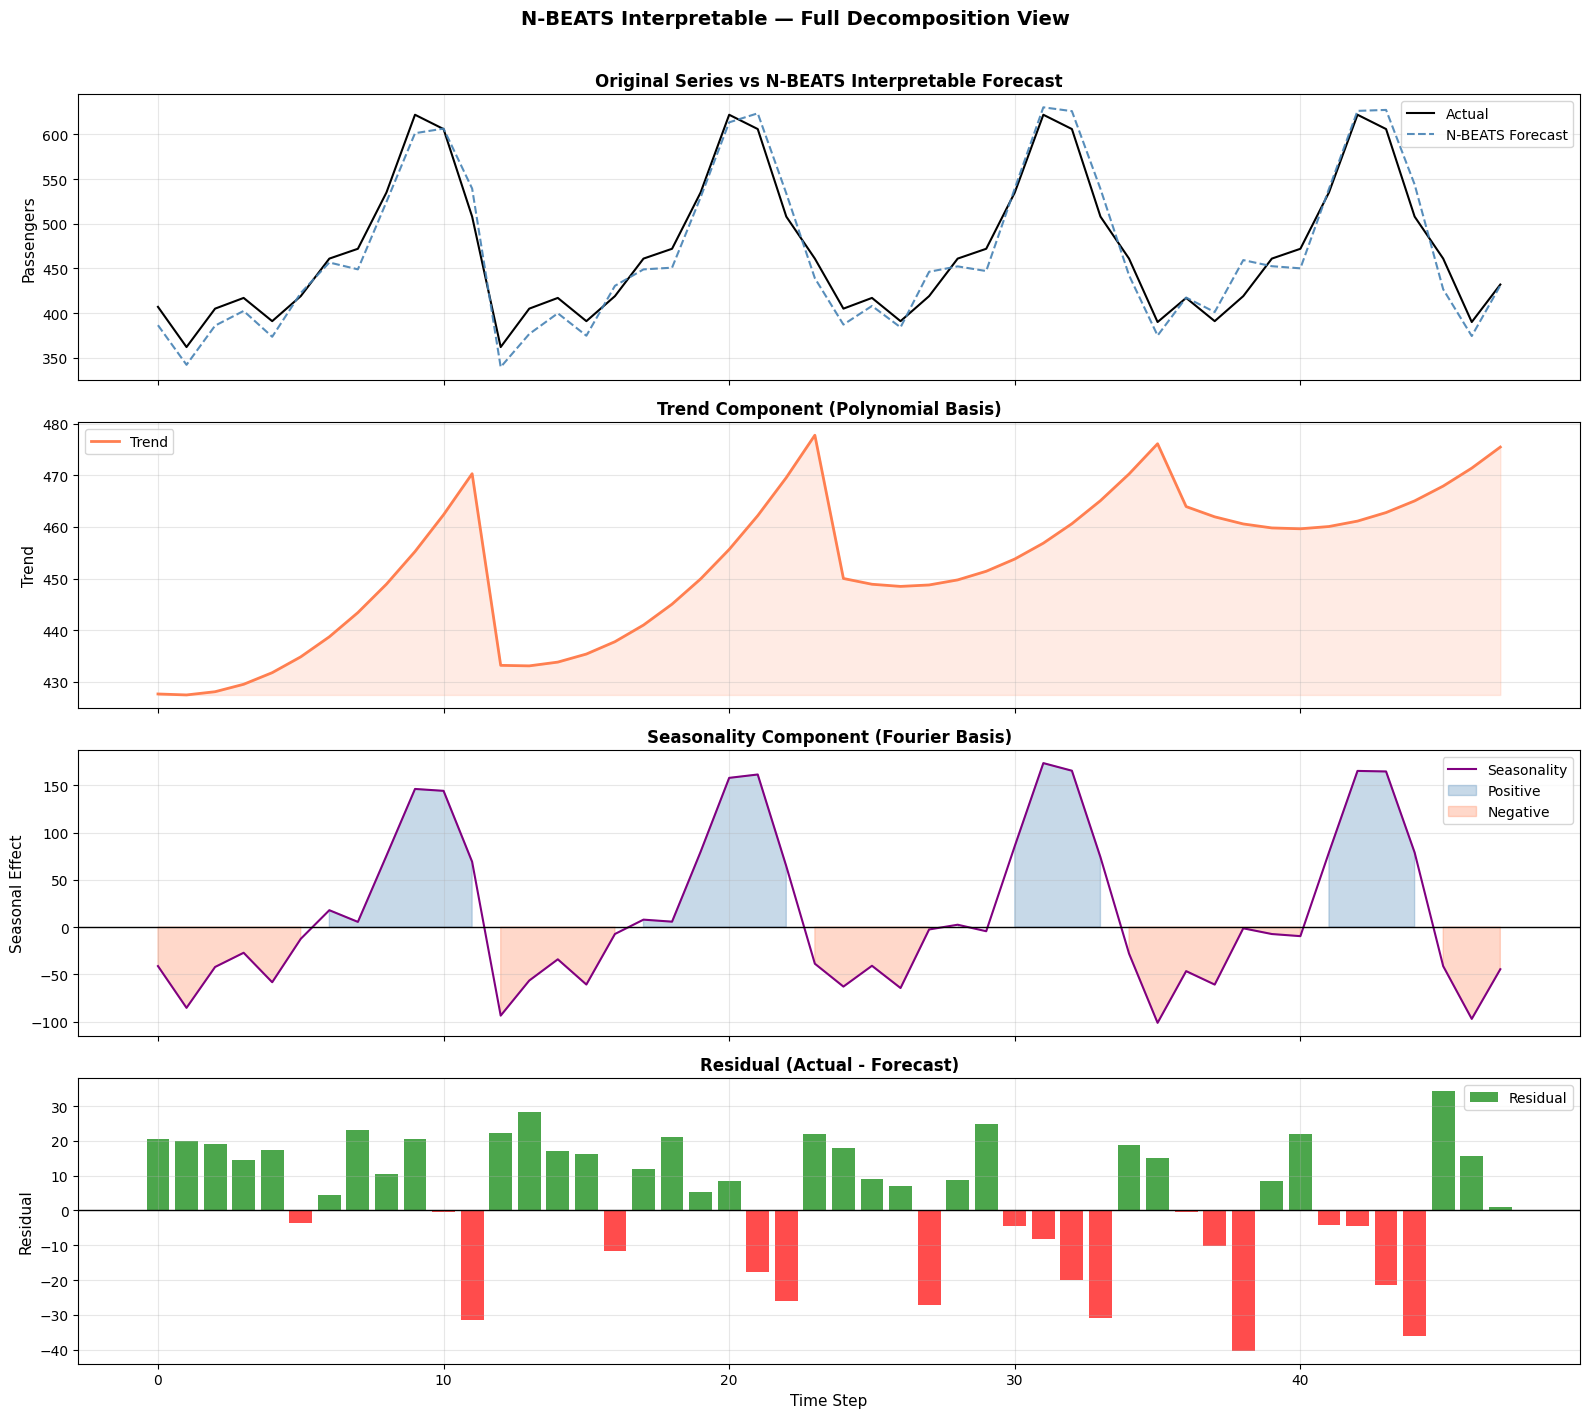

Saved: full_decomposition.png


In [ ]:
# Cell 15 — Full Time Series Decomposition (all test windows stitched together)

# Flatten all windows into a continuous view
flat_actual   = all_actuals.flatten()
flat_forecast = all_forecasts.flatten()
flat_trend    = all_trends.flatten()
flat_season   = all_seasons.flatten()
t_axis        = np.arange(len(flat_actual))

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

# Row 1: Actual vs Forecast
axes[0].plot(t_axis, flat_actual,   color='black',     linewidth=1.5, label='Actual')
axes[0].plot(t_axis, flat_forecast, color='steelblue', linewidth=1.5,
             linestyle='--', alpha=0.9, label='N-BEATS Forecast')
axes[0].set_ylabel('Passengers', fontsize=11)
axes[0].set_title('Original Series vs N-BEATS Interpretable Forecast', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# Row 2: Trend Component
axes[1].plot(t_axis, flat_trend, color='coral', linewidth=2, label='Trend')
axes[1].fill_between(t_axis, flat_trend.min(), flat_trend,
                     alpha=0.15, color='coral')
axes[1].set_ylabel('Trend', fontsize=11)
axes[1].set_title('Trend Component (Polynomial Basis)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

# Row 3: Seasonality Component
axes[2].plot(t_axis, flat_season, color='purple', linewidth=1.5, label='Seasonality')
axes[2].fill_between(t_axis, 0, flat_season,
                     where=(flat_season >= 0), alpha=0.3, color='steelblue', label='Positive')
axes[2].fill_between(t_axis, 0, flat_season,
                     where=(flat_season < 0),  alpha=0.3, color='coral',     label='Negative')
axes[2].axhline(y=0, color='black', linewidth=1.0)
axes[2].set_ylabel('Seasonal Effect', fontsize=11)
axes[2].set_title('Seasonality Component (Fourier Basis)', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10); axes[2].grid(True, alpha=0.3)

# Row 4: Residual (Actual - Forecast)
residual = flat_actual - flat_forecast
axes[3].bar(t_axis, residual,
            color=['green' if r >= 0 else 'red' for r in residual],
            alpha=0.7, label='Residual')
axes[3].axhline(y=0, color='black', linewidth=1.0)
axes[3].set_ylabel('Residual', fontsize=11)
axes[3].set_xlabel('Time Step',   fontsize=11)
axes[3].set_title('Residual (Actual - Forecast)', fontsize=12, fontweight='bold')
axes[3].legend(fontsize=10); axes[3].grid(True, alpha=0.3)

plt.suptitle('N-BEATS Interpretable — Full Decomposition View',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('full_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: full_decomposition.png')

  DECOMPOSITION STATISTICS SUMMARY
  Trend    — Mean  : 452.56
  Trend    — Std   : 14.23
  Trend    — Min   : 427.49
  Trend    — Max   : 477.75
--------------------------------------------------
  Season   — Mean  : 15.72
  Season   — Std   : 80.77
  Season   — Min   : -101.22
  Season   — Max   : 173.46
--------------------------------------------------
  Residual — Mean  : 3.91
  Residual — Std   : 18.61
  Residual — RMSE  : 19.02


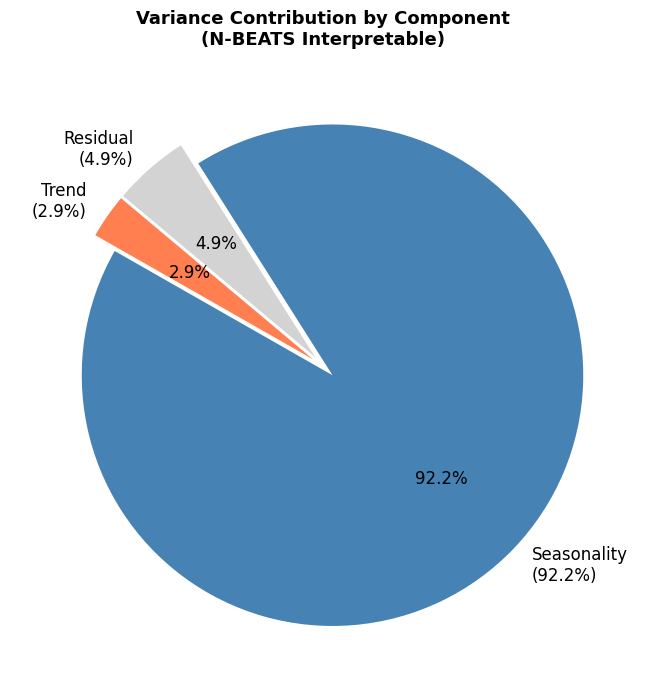

Saved: variance_contribution.png


In [ ]:
# Cell 16 — Trend & Seasonality Statistics Summary

print('=' * 50)
print('  DECOMPOSITION STATISTICS SUMMARY')
print('=' * 50)
print(f'  Trend    — Mean  : {flat_trend.mean():.2f}')
print(f'  Trend    — Std   : {flat_trend.std():.2f}')
print(f'  Trend    — Min   : {flat_trend.min():.2f}')
print(f'  Trend    — Max   : {flat_trend.max():.2f}')
print('-' * 50)
print(f'  Season   — Mean  : {flat_season.mean():.2f}')
print(f'  Season   — Std   : {flat_season.std():.2f}')
print(f'  Season   — Min   : {flat_season.min():.2f}')
print(f'  Season   — Max   : {flat_season.max():.2f}')
print('-' * 50)
print(f'  Residual — Mean  : {residual.mean():.2f}')
print(f'  Residual — Std   : {residual.std():.2f}')
print(f'  Residual — RMSE  : {np.sqrt(np.mean(residual**2)):.2f}')
print('=' * 50)

# Pie chart: variance contribution of each component
var_trend  = np.var(flat_trend)
var_season = np.var(flat_season)
var_resid  = np.var(residual)
total_var  = var_trend + var_season + var_resid

labels  = [
    f'Trend\n({100*var_trend/total_var:.1f}%)',
    f'Seasonality\n({100*var_season/total_var:.1f}%)',
    f'Residual\n({100*var_resid/total_var:.1f}%)'
]
sizes   = [var_trend, var_season, var_resid]
colors  = ['coral', 'steelblue', 'lightgray']
explode = (0.05, 0.05, 0.05)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(sizes, labels=labels, colors=colors, explode=explode,
       autopct='%1.1f%%', startangle=140,
       textprops={'fontsize': 12})
ax.set_title('Variance Contribution by Component\n(N-BEATS Interpretable)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('variance_contribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: variance_contribution.png')